In [7]:
import numpy as np 
import pandas as pd 

In [8]:
df_train = pd.read_csv('../input/tabular-playground-series-nov-2021/train.csv')
df_test = pd.read_csv('../input/tabular-playground-series-nov-2021/test.csv')
submission = pd.read_csv('../input/tabular-playground-series-nov-2021/sample_submission.csv')

In [9]:
features = [col for col in df_train.columns if 'f' in col]

### Observing the test data

<AxesSubplot:xlabel='target', ylabel='count'>

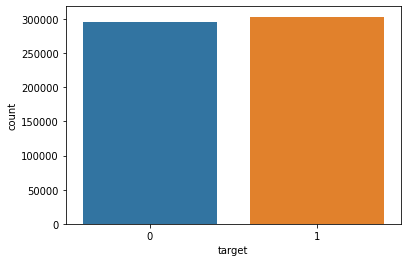

In [10]:
import seaborn as sns

sns.countplot(x = 'target', data = df_train)

### Conclusion

The distribution of data with target = 0 and target = 1 made are the same. This is one less thing to worry about :)

In [11]:
print(df_train[features].isna().sum().sum())
print(df_test[features].isna().sum().sum())

0
0


In [14]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

# the number 2 is just a threshold to split 
h_skew = list(df_train.loc[:,df_train.skew() >= 2].columns)  
l_skew = list(df_train.loc[:,df_train.skew() < 2].columns)   

#h_skew.remove('target')
l_skew.remove('target')

df_train['median_h'] = df_train[h_skew].median(axis=1)
df_test['median_h'] = df_test[h_skew].median(axis=1)

df_train['median_l'] = df_train[l_skew].median(axis=1)
df_test['median_l'] = df_test[l_skew].median(axis=1)

features.append('median_h')
features.append('median_l')

In [15]:
X = df_train[features].copy()
y = df_train['target'].copy()

x_test = df_test[features].copy()

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[features] = scaler.fit_transform(X[features])
x_test[features] = scaler.transform(x_test[features])

### Let's build a simple Neural Network

In [17]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks

import tensorflow as tf
import random
import os

my_seed = 42

input_shape = [X.shape[1]]
PATIENCE = 10
MIN_DELTA = 0.0005

model = keras.Sequential([
    layers.BatchNormalization(input_shape=input_shape),
    layers.Dense(units=128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(units=64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(units=1, activation='sigmoid')
])

model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['AUC'])

early_stopping = keras.callbacks.EarlyStopping(
    patience=15,
    min_delta=MIN_DELTA,
    restore_best_weights=True,
)

2021-11-20 12:34:23.642983: W tensorflow/stream_executor/platform/default/dso_loader.cc:60] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/conda/lib
2021-11-20 12:34:23.643767: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2021-11-20 12:34:28.998361: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2021-11-20 12:34:29.001135: W tensorflow/stream_executor/platform/default/dso_loader.cc:60] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/conda/lib
2021-11-20 12:34:29.001174: W tensorflow/stream_executor/cuda/cuda_driver.cc:326] failed call to cuInit: UNKNOWN ERROR (303)
2021-11-20 12:34:29.001215: I tensorflow/stream_executor/cuda/cud

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization (BatchNo (None, 102)               408       
_________________________________________________________________
dense (Dense)                (None, 128)               13184     
_________________________________________________________________
batch_normalization_1 (Batch (None, 128)               512       
_________________________________________________________________
dropout (Dropout)            (None, 128)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 64)                8256      
_________________________________________________________________
batch_normalization_2 (Batch (None, 64)                256       
_________________________________________________________________
dropout_1 (Dropout)          (None, 64)                0

### Training model 

In [24]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

EPOCHS = 700
BATCH_SIZE = 2048 
ACTIVATION = 'swish'
LEARNING_RATE = 0.0007
RANDOM_SEED = 42
n_splits = 5

skf = StratifiedKFold(n_splits = n_splits, shuffle = True, random_state = RANDOM_SEED)

preds_test_nn = []
mean_auc = 0

best_nn_model = None
best_roc_score_nn = 0

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.loc[train_idx], X.loc[val_idx]
    y_train, y_val = y.loc[train_idx], y.loc[val_idx]
    
    model.fit(X_train, y_train,
             verbose = 0,
             validation_data = (X_val, y_val),
             batch_size = BATCH_SIZE, 
             epochs = EPOCHS,
             callbacks = [early_stopping],
             shuffle = True)
   
    y_pred = model.predict(X_val)
    score = roc_auc_score(y_val, y_pred)
    mean_auc += score
    
    
    if score>best_roc_score_nn:
        best_roc_score_nn = score
        best_nn_model = model
    
    print(f"Fold {fold}'s score: {score}")
        
    preds_test_nn.append(model.predict(x_test).reshape(1,-1)[0])

print("==========================================")
print(f"Mean auc of all folds: {mean_auc / n_splits}")

Fold 0's score: 0.7563618039934861
Fold 1's score: 0.7685732991423332
Fold 2's score: 0.7700839340839939
Fold 3's score: 0.7706691877614541
Fold 4's score: 0.7719329185498649
Mean auc of all folds: 0.7675242287062265


In [27]:
submission = pd.DataFrame()
submission['id'] = df_test['id']
submission['target'] = np.mean(preds_test_nn, axis = 0)

In [28]:
submission.to_csv('submission', index=False)